# ASSIGNMENT 6: IIR filters and specification based design

IIR filters are widely used when you need a sharp frequency response with a low number of coefficients. Compared to FIR filters, IIR filters often reach similar magnitude specifications with a much lower filter order, which reduces computation and delay. The tradeoff is that IIR filters typically have a more nonlinear phase response and they can be more sensitive to numerical effects in implementation.

In this assignment you will design lowpass IIR filters from four classical families: Butterworth, Chebyshev Type I, Chebyshev Type II, and elliptic. These families are derived from analogue prototypes and converted to digital filters using the bilinear transform inside SciPy. All designs in this notebook are driven by frequency domain specifications.

The function `scipy.signal.iirdesign(wp, ws, gpass, gstop, ftype=...)` constructs a minimum order filter that meets the constraints:
- `wp` is the passband edge frequency
- `ws` is the stopband edge frequency
- `gpass` is the maximum allowed passband ripple in dB
- `gstop` is the required minimum stopband attenuation in dB

In this notebook, the frequencies are normalized to the range [0, 1], where 1 corresponds to the Nyquist frequency. This means that a value of 0.25 corresponds to 0.25 times the Nyquist frequency.

Your goal is to compare the designed filters in a systematic way. Use the visualizations to identify where ripple appears, how sharp the transition band is, and how the phase behaves. These are the key practical differences between the filter families.

## Specification based IIR filter design in Python
The Python package `scipy.signal` contains functions to perform IIR filter design using bilinear z-transform (BZT) step-by-step, but it also contains functions which combine all the steps into one. With these functions it is possible to construct IIR filters which are based on analogue Butterworth, Chebyshev Type 1, Chebyshev Type 2 or Elliptic filters. In this task `scipy.signal.iirdesign` is used to create a filter and `fvtool` is used to visualize it.

The function `scipy.signal.iirdesign` takes the desired pass band edge frequency, stop band edge frequency, passband ripple and stopband attenuation as arguments and constructs an IIR filter of minimum order fulfilling the criteria. For example, a Butterworth filter with a passband edge frequency of 0.15, stopband edge frequency of 0.275, passband ripple of 2 dB and stopband attenuation of 60 dB can be created with:
```python
b, a = signal.iirdesign(0.15, 0.275, 2, 60, ftype='butter')
```
The function returns the coefficients of the numerator (b) and the denominator (a) of the IIR filter. You can use `ftype='butter'` to design a Butterworth filter, `ftype='cheby1'` for a Chebyshev Type 1 filter, `ftype='cheby2'` for a Chebyshev Type 2 filter and `ftype='ellip'` for an elliptic filter. See the documentation of the function for more details: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.iirdesign.html

Start by running the code block below to load the Python packages required to complete this assignment. To run the code, select the code block and push Ctrl+Enter or click the Run button.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from dftools import fvtool

**Task 6.1**
Using *iirdesign*, design four different lowpass IIR filters: Butterworth, Chebyshev I and II, and elliptic. Use the following parameters for the filters: normalized pass band edge frequency 0.25, normalized stop band edge frequency 0.3 (normalized to range [0,1]), ripple in passband 2 dB and attenuation in stopband 60 dB. **Examine the properties of each filter and answer the following questions.** Use `fvtool` to visualize the filters. The arguments to the function `fvtool` are the numerator b and denominator a of the digital filter, as well as the same design parameters that are passed to the function *iirdesign* (except for the filter type). For example, the filter above could be visualized with
```python
fvtool(b, a, 0.15, 0.275, 2, 60)
```
You can see the details of the function `fvtool` in the file dftools.py provided with this assignment.

In [2]:
# use signal.iirdesign to create the filters
wp = 0.25  # passband edge frequency
ws = 0.3   # stopband edge frequency
gpass = 2  # passband ripple in dB
gstop = 60 # stopband attenuation in dB

# Butterworth filter
b_butter, a_butter = signal.iirdesign(wp, ws, gpass, gstop, ftype='butter')

# Chebyshev Type I filter
b_cheby1, a_cheby1 = signal.iirdesign(wp, ws, gpass, gstop, ftype='cheby1')

# Chebyshev Type II filter
b_cheby2, a_cheby2 = signal.iirdesign(wp, ws, gpass, gstop, ftype='cheby2')

# Elliptic filter
b_ellip, a_ellip = signal.iirdesign(wp, ws, gpass, gstop, ftype='ellip')

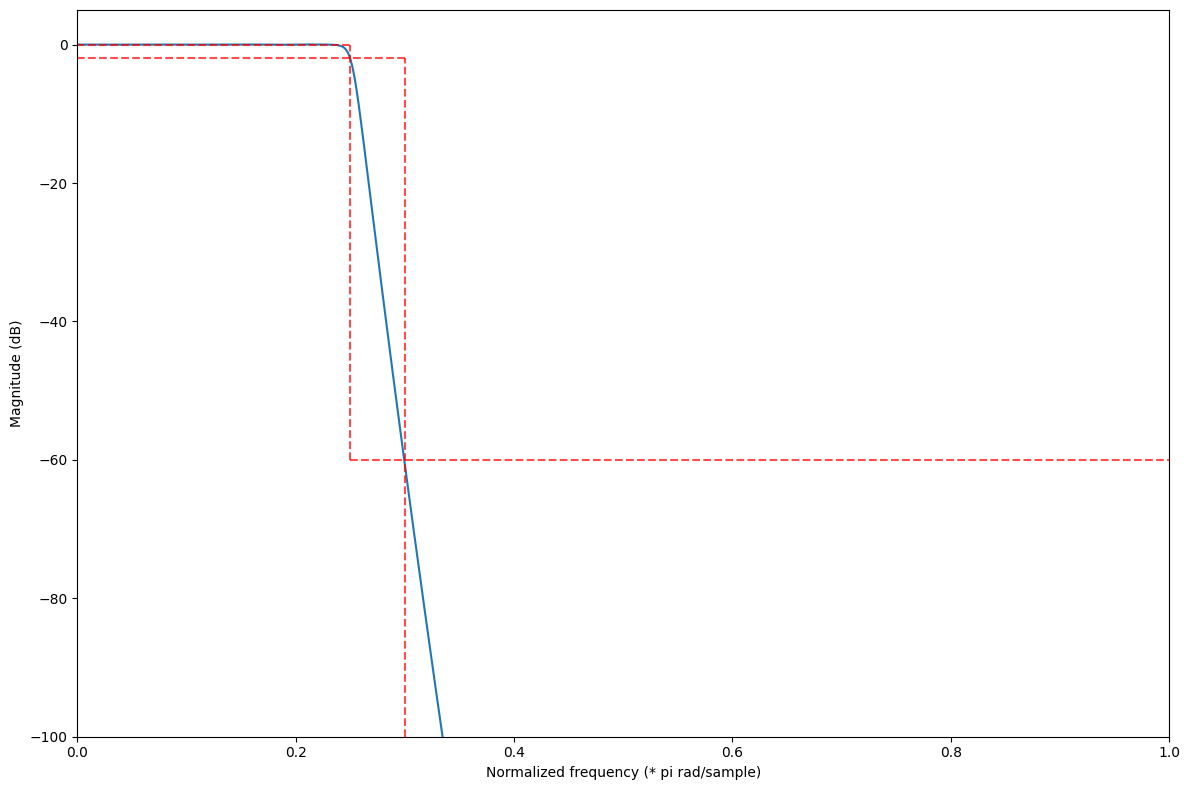

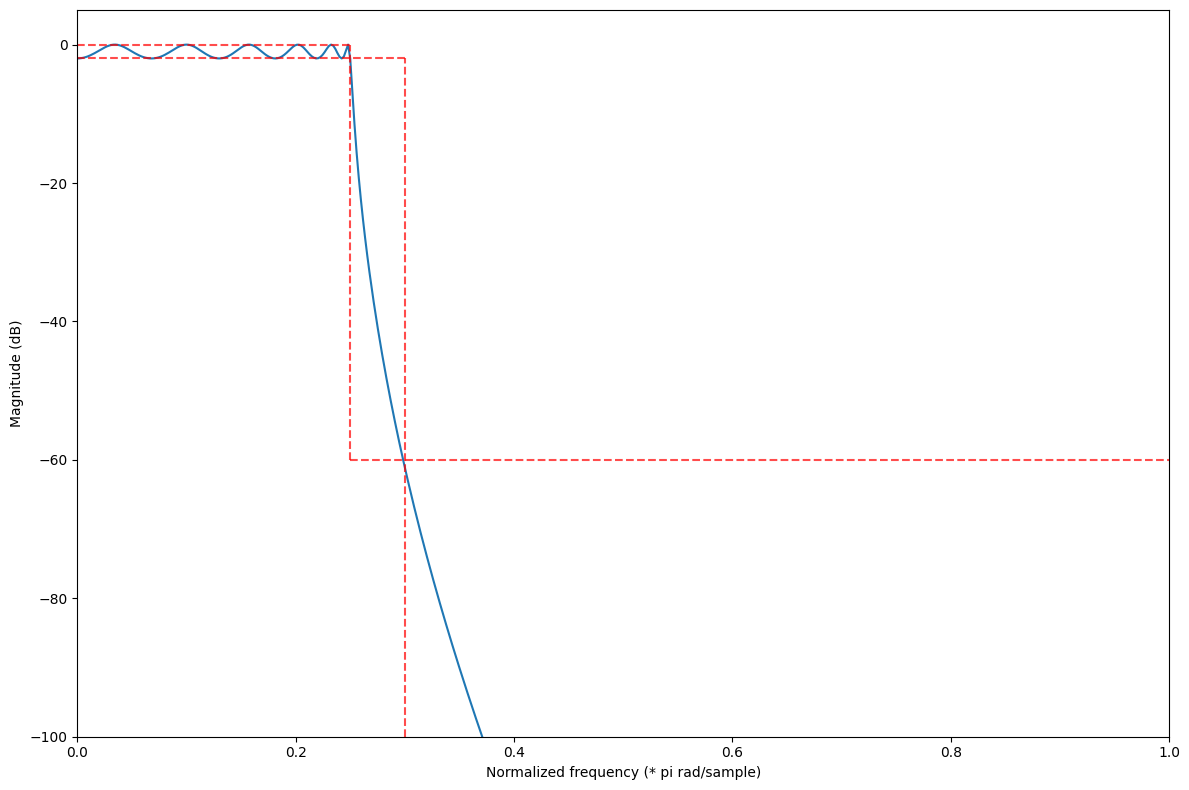

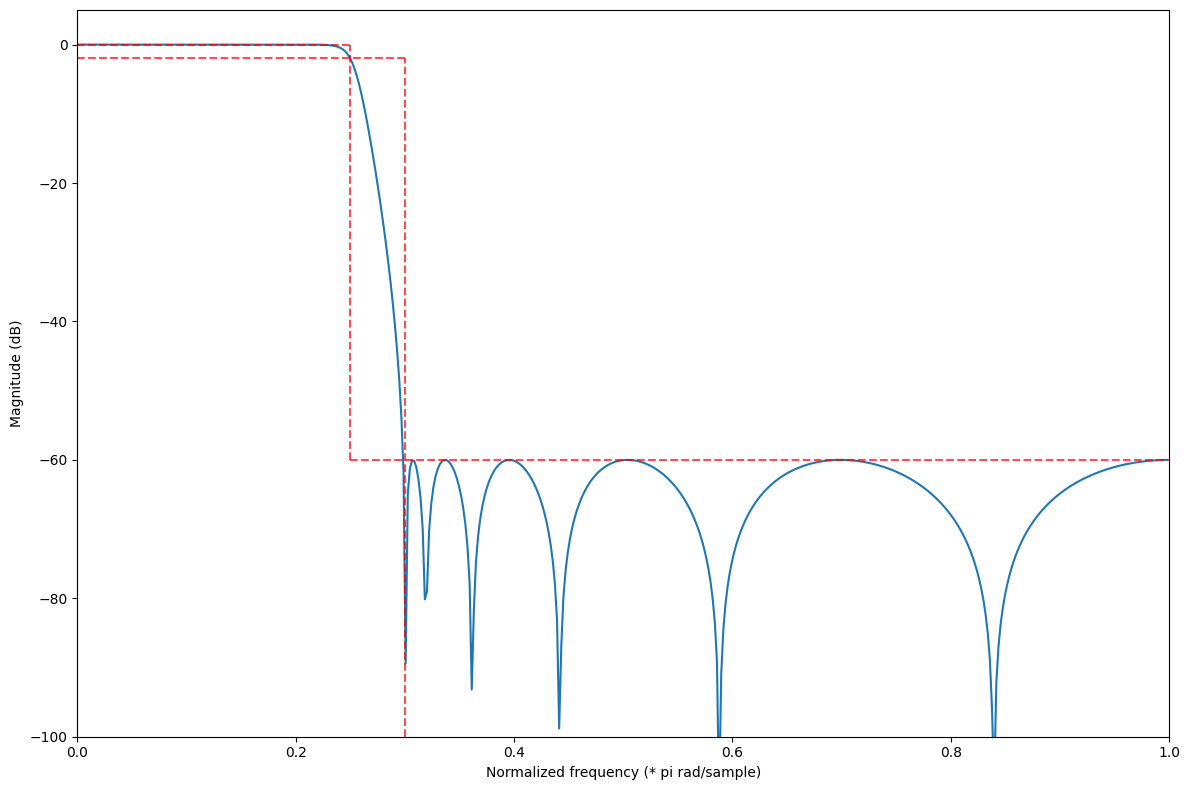

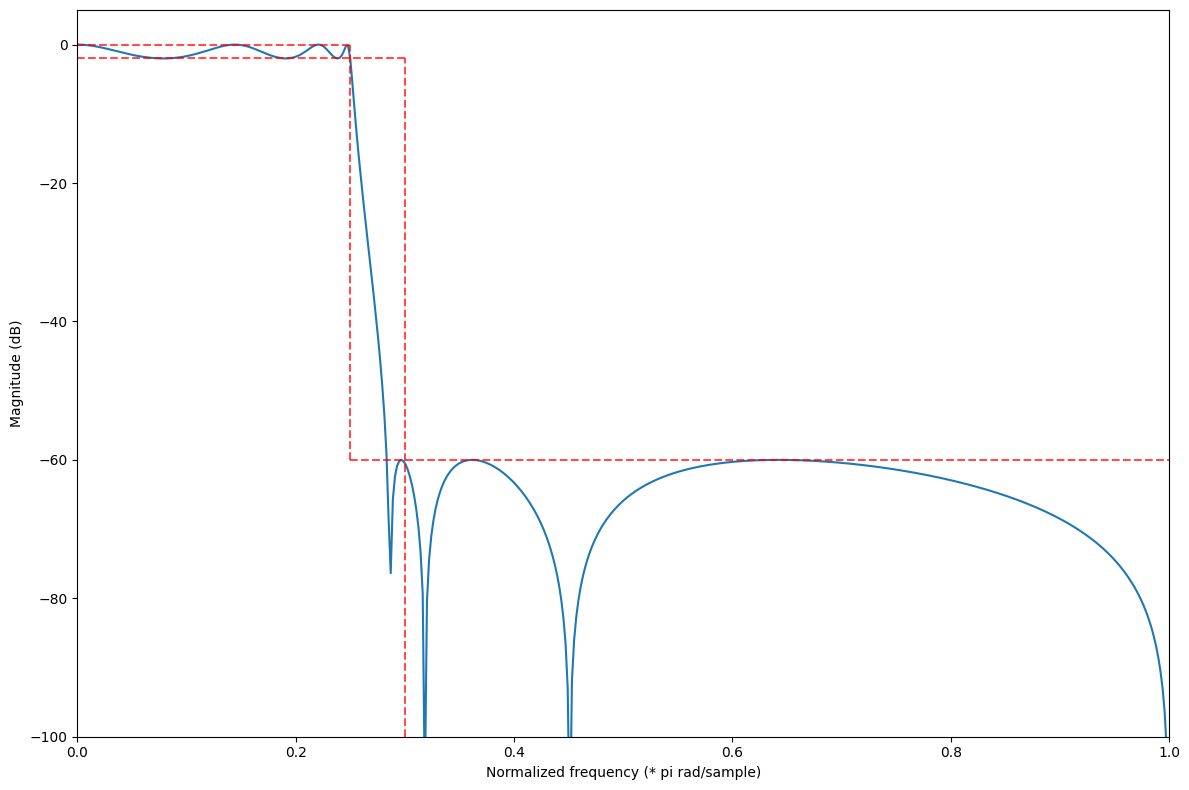

In [3]:
# visualize the magnitude responses of the filters using fvtool
fvtool(b_butter, a_butter, wp, ws, gpass, gstop)

fvtool(b_cheby1, a_cheby1, wp, ws, gpass, gstop)

fvtool(b_cheby2, a_cheby2, wp, ws, gpass, gstop)

fvtool(b_ellip, a_ellip, wp, ws, gpass, gstop)

**Is there ripple in the passbands of the filters?**


- Butterworth filter: No ripples
- Chebyshev Type I filter: Equiripple in the passband and a monotonic stopband. The ripple would be up to 2 dB as specified in the design parameters.
- Chebyshev Type II filter: No ripples
- Elliptic filter: Equiripple in both the passband and stopband, with the passband ripple up to the specified 2 dB.

## Mini exercise: filtering white noise with IIR and FIR lowpass filters (optional)

White noise is a random signal whose power is spread across frequencies. It is commonly used to test filters because the effect of a lowpass filter is visible in the spectrum and audible as a reduction of high-frequency content.

In this mini exercise you will generate white noise, design one IIR lowpass filter and one FIR lowpass filter using the same specification, filter the noise, and compare the results.

Run the code below, listen the audio signals, visualize the spectral response, and answer the question at the end:


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

try:
    from IPython.display import Audio, display
    audio_ok = True
except Exception:
    audio_ok = False

# Reproducibility
np.random.seed(0)

# Sampling settings for audio-like playback
fs = 22050          # Hz
duration = 3.0      # seconds
N = int(fs * duration)

# Generate white noise and scale it to a comfortable level
x = np.random.randn(N)
x = 0.3 * x / np.max(np.abs(x))

# Design specification (normalized to Nyquist, range [0, 1])
wp = 0.25   # passband edge
ws = 0.30   # stopband edge
gpass = 2   # dB
gstop = 60  # dB

# IIR design (use SOS for numerical stability)
sos = signal.iirdesign(wp, ws, gpass, gstop, ftype="ellip", output="sos")

# FIR design (Kaiser window estimate for given attenuation and transition width)
width = ws - wp
numtaps, beta = signal.kaiserord(gstop, width)
if numtaps % 2 == 0:
    numtaps += 1  # enforce odd length for Type I linear-phase FIR
b_fir = signal.firwin(numtaps, cutoff=wp, window=("kaiser", beta))

# Filter the noise
y_iir = signal.sosfilt(sos, x)
y_fir = signal.lfilter(b_fir, [1.0], x)

# Scale filtered signals to avoid clipping in playback
y_iir = 0.3 * y_iir / np.max(np.abs(y_iir))
y_fir = 0.3 * y_fir / np.max(np.abs(y_fir))

# Optional listening in Jupyter
if audio_ok:
    print("Original white noise")
    display(Audio(x, rate=fs))
    print("Filtered with IIR (elliptic)")
    display(Audio(y_iir, rate=fs))
    print("Filtered with FIR (Kaiser)")
    display(Audio(y_fir, rate=fs))
else:
    print("Audio playback is not available in this environment.")

Original white noise


Filtered with IIR (elliptic)


Filtered with FIR (Kaiser)


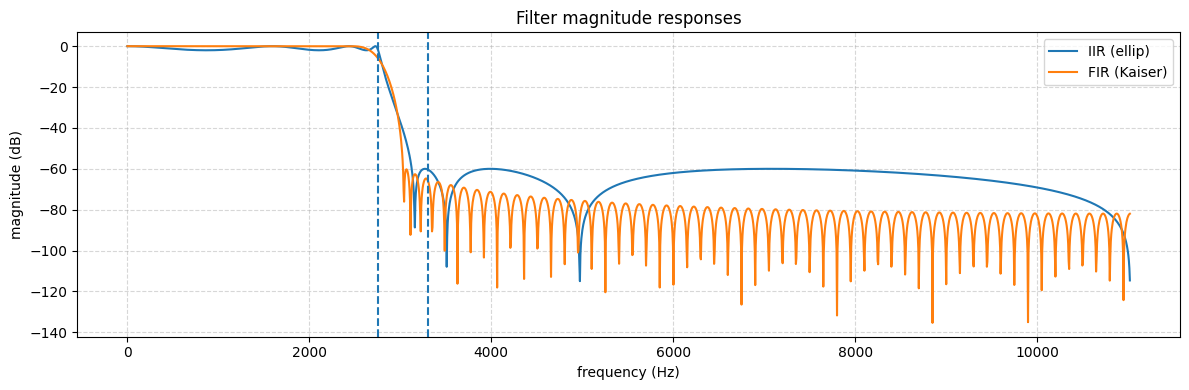

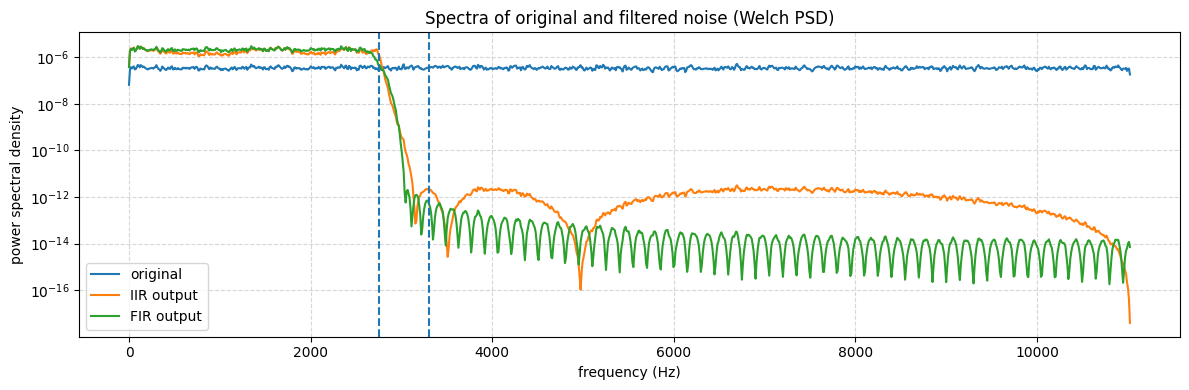

IIR sections (SOS): 4 Approx IIR order: 8
FIR number of taps: 147


In [7]:
# Frequency responses
w_iir, H_iir = signal.sosfreqz(sos, worN=2048)
w_fir, H_fir = signal.freqz(b_fir, [1.0], worN=2048)

f_iir = (w_iir / np.pi) * (fs / 2)
f_fir = (w_fir / np.pi) * (fs / 2)

plt.figure(figsize=(12, 4))
plt.plot(f_iir, 20*np.log10(np.maximum(np.abs(H_iir), 1e-12)), label="IIR (ellip)")
plt.plot(f_fir, 20*np.log10(np.maximum(np.abs(H_fir), 1e-12)), label="FIR (Kaiser)")
plt.axvline(wp*(fs/2), linestyle="--")
plt.axvline(ws*(fs/2), linestyle="--")
plt.xlabel("frequency (Hz)")
plt.ylabel("magnitude (dB)")
plt.title("Filter magnitude responses")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Spectral comparison using Welch PSD
f_psd, Pxx = signal.welch(x, fs=fs, nperseg=2048)
_, Pyy_iir = signal.welch(y_iir, fs=fs, nperseg=2048)
_, Pyy_fir = signal.welch(y_fir, fs=fs, nperseg=2048)

plt.figure(figsize=(12, 4))
plt.semilogy(f_psd, Pxx, label="original")
plt.semilogy(f_psd, Pyy_iir, label="IIR output")
plt.semilogy(f_psd, Pyy_fir, label="FIR output")
plt.axvline(wp*(fs/2), linestyle="--")
plt.axvline(ws*(fs/2), linestyle="--")
plt.xlabel("frequency (Hz)")
plt.ylabel("power spectral density")
plt.title("Spectra of original and filtered noise (Welch PSD)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Basic complexity comparison
iir_order = 2 * sos.shape[0]
fir_len = len(b_fir)
print("IIR sections (SOS):", sos.shape[0], "Approx IIR order:", iir_order)
print("FIR number of taps:", fir_len)

Short questions (answer briefly):
1) When you listen to the signals, how does the filtered noise sound compared to the original. Does the IIR and FIR output sound similar or different.
2) Compare the output spectra. Do both filters remove high-frequency content as expected. Are there differences near the transition band.
3) Compare the filter lengths and orders. Which design achieves the specification with fewer coefficients.
4) Optional: compare phase or group delay between IIR and FIR using the plots.

The filtered noise sounds noticeably muffled relative to the original, and the IIR and FIR outputs sound broadly similar.


Yes, both filters remove high‑frequency content as intended, but the FIR shows a sharper, cleaner cutoff while the IIR exhibits some ripple near the transition band.


The IIR design meets the specification with far fewer coefficients, since the elliptic IIR achieves the same attenuation using only a small number of SOS sections compared to the long FIR.

The IIR shows nonlinear and frequency‑dependent group delay, whereas the FIR exhibits nearly constant (linear‑phase) delay across the passband.

### Instructions for submission
1. Make sure that your code produces the desired results from scratch by selecting Kernel -> Restart & Run all. This will clear the output of your code and run all the code cells again from top to bottom.

2. Rename this notebook to `DF_Assignment6_firstname_lastname_studentnumber.ipynb`.

3. Submit only the resulting notebook (.ipynb file) to the return box in Moodle. Send your submission before the deadline to receive additional week exam points.